# LLM-as-a-Judge: Tutor Feedback Evaluation


\*The LLM-as-a-Judge code for evalaution is on the "LLM-as-a-judge devset.ipynb" notebook


In [ ]:
import json

### Analyze Results

Summary statistics of the scoring:


In [20]:
refinements_file = "outputs/mrbench_v3_testset_refinements.jsonl"
conversations_file = "BEA Dataset/mrbench_v3_testset.json"
output_file = "outputs/llm_judge_scores_testset.json"

In [29]:
results = json.load(open(output_file, 'r', encoding='utf-8'))

In [30]:
# Analyze the results
from statistics import pstdev

print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

original_overall = []
refined_overall = []
original_by_criterion = {c: [] for c in criteria}
refined_by_criterion = {c: [] for c in criteria}

for result in results:
    original_scores = result['llm_judge_scores'].get('original_scores', {})
    refined_scores = result['llm_judge_scores'].get('refined_scores', {})

    if original_scores:
        overall = original_scores.get('overall_score')
        if overall is not None:
            original_overall.append(overall)
        for c in criteria:
            score = original_scores.get(c, {}).get('score')
            if score is not None:
                original_by_criterion[c].append(score)

    if refined_scores:
        overall = refined_scores.get('overall_score')
        if overall is not None:
            refined_overall.append(overall)
        for c in criteria:
            score = refined_scores.get(c, {}).get('score')
            if score is not None:
                refined_by_criterion[c].append(score)


def safe_std(values):
    return pstdev(values) if len(values) > 1 else 0.0


def format_stats(values):
    if not values:
        return "Count: 0 | Average: n/a | Std Dev: n/a"
    avg = sum(values) / len(values)
    std = safe_std(values)
    return f"Count: {len(values)} | Average: {avg:.2f} | Std Dev: {std:.2f}"


print("\nOverall:")
print(f"  Original -> {format_stats(original_overall)}")
print(f"  Refined  -> {format_stats(refined_overall)}")

for c in criteria:
    print(f"\n{c}:")
    print(f"  Original -> {format_stats(original_by_criterion[c])}")
    print(f"  Refined  -> {format_stats(refined_by_criterion[c])}")

if original_overall and refined_overall:
    avg_improvement = sum(refined_overall)/len(refined_overall) - sum(original_overall)/len(original_overall)
    print(f"\nAverage Improvement: {avg_improvement:+.2f}")

SUMMARY STATISTICS

Overall:
  Original -> Count: 1010 | Average: 2.07 | Std Dev: 0.66
  Refined  -> Count: 1010 | Average: 2.89 | Std Dev: 0.22

mistake_identification:
  Original -> Count: 1010 | Average: 2.07 | Std Dev: 0.89
  Refined  -> Count: 1010 | Average: 2.83 | Std Dev: 0.44

mistake_location:
  Original -> Count: 1010 | Average: 2.20 | Std Dev: 0.80
  Refined  -> Count: 1010 | Average: 2.90 | Std Dev: 0.31

providing_guidance:
  Original -> Count: 1010 | Average: 1.90 | Std Dev: 0.78
  Refined  -> Count: 1010 | Average: 2.86 | Std Dev: 0.36

actionability:
  Original -> Count: 1010 | Average: 2.10 | Std Dev: 0.72
  Refined  -> Count: 1010 | Average: 2.98 | Std Dev: 0.14

Average Improvement: +0.82


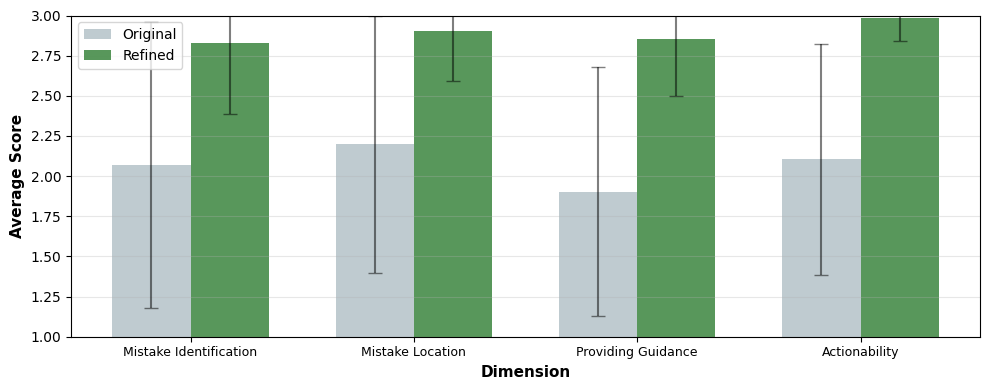

In [31]:
# Graph visualization of summary statistics from cell 24
import matplotlib.pyplot as plt
import numpy as np
from statistics import pstdev

# Recalculate statistics
criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

original_overall = []
refined_overall = []
original_by_criterion = {c: [] for c in criteria}
refined_by_criterion = {c: [] for c in criteria}

for result in results:
    original_scores = result['llm_judge_scores'].get('original_scores', {})
    refined_scores = result['llm_judge_scores'].get('refined_scores', {})

    if original_scores:
        overall = original_scores.get('overall_score')
        if overall is not None:
            original_overall.append(overall)
        for c in criteria:
            score = original_scores.get(c, {}).get('score')
            if score is not None:
                original_by_criterion[c].append(score)

    if refined_scores:
        overall = refined_scores.get('overall_score')
        if overall is not None:
            refined_overall.append(overall)
        for c in criteria:
            score = refined_scores.get(c, {}).get('score')
            if score is not None:
                refined_by_criterion[c].append(score)

def safe_std(values):
    return pstdev(values) if len(values) > 1 else 0.0

labels = {
    "mistake_identification": "Mistake Identification",
    "mistake_location": "Mistake Location",
    "providing_guidance": "Providing Guidance",
    "actionability": "Actionability",
}

# Prepare data for plotting
criterion_labels = [labels[c] for c in criteria]
original_means = [np.mean(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_means = [np.mean(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]
original_stds = [safe_std(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_stds = [safe_std(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]

# Create figure with subplot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Plot 1: Per-Criterion Comparison
x = np.arange(len(criteria))
width = 0.35

bars1 = ax1.bar(x - width/2, original_means, width, label='Original', color='#B0BEC5', alpha=0.8, capsize=5)
bars2 = ax1.bar(x + width/2, refined_means, width, label='Refined', color='#2E7D32', alpha=0.8, capsize=5)

# Add error bars
ax1.errorbar(x - width/2, original_means, yerr=original_stds, fmt='none', color='black', capsize=5, alpha=0.5)
ax1.errorbar(x + width/2, refined_means, yerr=refined_stds, fmt='none', color='black', capsize=5, alpha=0.5)

ax1.set_xlabel('Dimension', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Score', fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(criterion_labels, fontsize=9)
ax1.set_ylim([1, 3])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

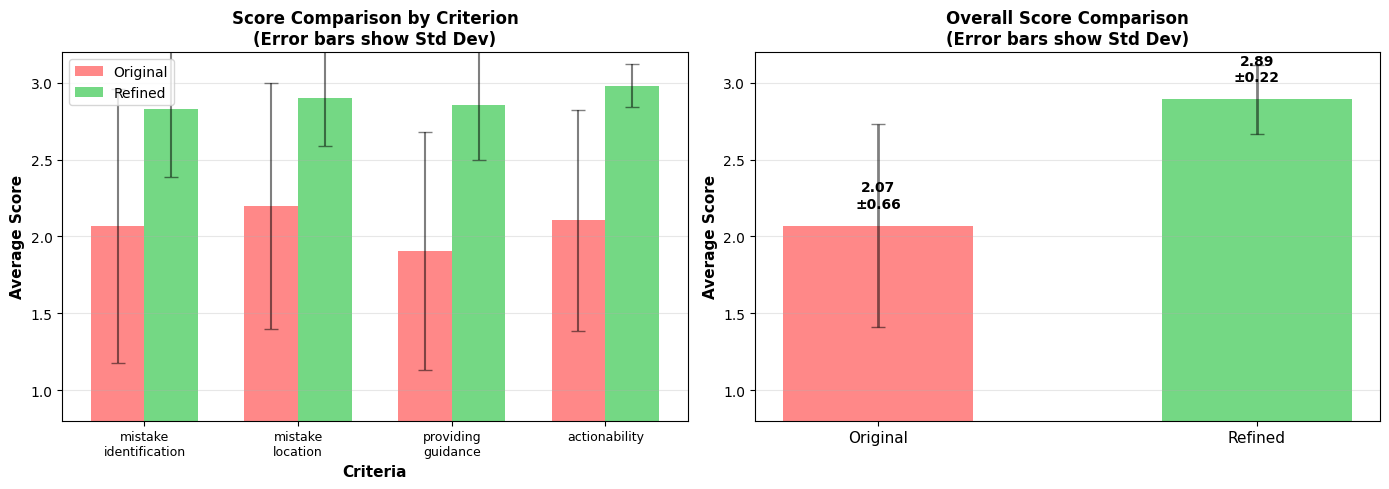

In [32]:
# Graph visualization of summary statistics from cell 24
import matplotlib.pyplot as plt
import numpy as np
from statistics import pstdev

# Recalculate statistics
criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

original_overall = []
refined_overall = []
original_by_criterion = {c: [] for c in criteria}
refined_by_criterion = {c: [] for c in criteria}

for result in results:
    original_scores = result['llm_judge_scores'].get('original_scores', {})
    refined_scores = result['llm_judge_scores'].get('refined_scores', {})

    if original_scores:
        overall = original_scores.get('overall_score')
        if overall is not None:
            original_overall.append(overall)
        for c in criteria:
            score = original_scores.get(c, {}).get('score')
            if score is not None:
                original_by_criterion[c].append(score)

    if refined_scores:
        overall = refined_scores.get('overall_score')
        if overall is not None:
            refined_overall.append(overall)
        for c in criteria:
            score = refined_scores.get(c, {}).get('score')
            if score is not None:
                refined_by_criterion[c].append(score)

def safe_std(values):
    return pstdev(values) if len(values) > 1 else 0.0

# Prepare data for plotting
criterion_labels = [c.replace('_', '\n') for c in criteria]
original_means = [np.mean(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_means = [np.mean(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]
original_stds = [safe_std(original_by_criterion[c]) if original_by_criterion[c] else 0 for c in criteria]
refined_stds = [safe_std(refined_by_criterion[c]) if refined_by_criterion[c] else 0 for c in criteria]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Per-Criterion Comparison
ax1 = axes[0]
x = np.arange(len(criteria))
width = 0.35

bars1 = ax1.bar(x - width/2, original_means, width, label='Original', color='#FF6B6B', alpha=0.8, capsize=5)
bars2 = ax1.bar(x + width/2, refined_means, width, label='Refined', color='#51CF66', alpha=0.8, capsize=5)

# Add error bars
ax1.errorbar(x - width/2, original_means, yerr=original_stds, fmt='none', color='black', capsize=5, alpha=0.5)
ax1.errorbar(x + width/2, refined_means, yerr=refined_stds, fmt='none', color='black', capsize=5, alpha=0.5)

ax1.set_xlabel('Criteria', fontsize=11, fontweight='bold')
ax1.set_ylabel('Average Score', fontsize=11, fontweight='bold')
ax1.set_title('Score Comparison by Criterion\n(Error bars show Std Dev)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(criterion_labels, fontsize=9)
ax1.set_ylim([0.8, 3.2])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Overall Score Comparison
ax2 = axes[1]
overall_orig_mean = np.mean(original_overall) if original_overall else 0
overall_refined_mean = np.mean(refined_overall) if refined_overall else 0
overall_orig_std = safe_std(original_overall)
overall_refined_std = safe_std(refined_overall)

x_pos = [0, 1]
means = [overall_orig_mean, overall_refined_mean]
stds = [overall_orig_std, overall_refined_std]
colors = ['#FF6B6B', '#51CF66']
labels = ['Original', 'Refined']

bars = ax2.bar(x_pos, means, color=colors, alpha=0.8, capsize=5, width=0.5)
ax2.errorbar(x_pos, means, yerr=stds, fmt='none', color='black', capsize=5, alpha=0.5, linewidth=2)

# Add value labels on bars
for i, (bar, mean, std) in enumerate(zip(bars, means, stds)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{mean:.2f}\n±{std:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Average Score', fontsize=11, fontweight='bold')
ax2.set_title('Overall Score Comparison\n(Error bars show Std Dev)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim([0.8, 3.2])
ax2.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()


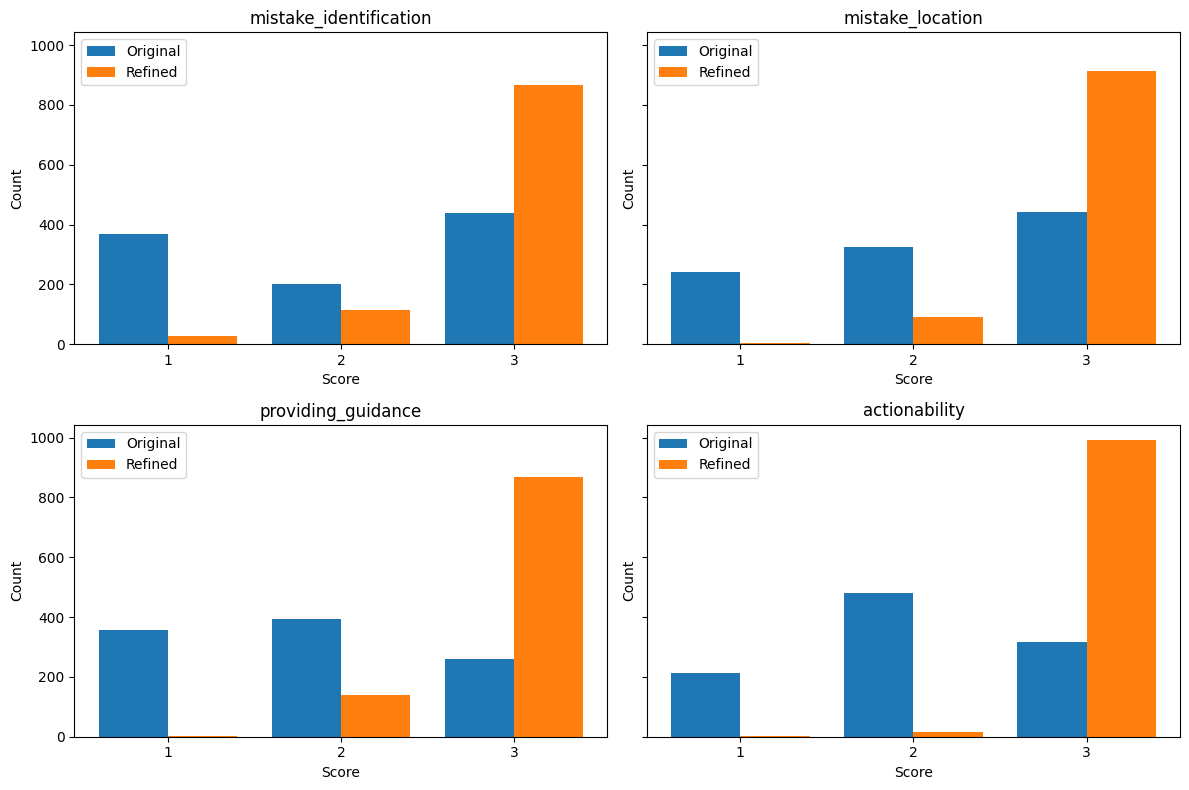

In [33]:
# Distribution plots for each criterion (Original vs Refined)
import matplotlib.pyplot as plt

criteria = [
    "mistake_identification",
    "mistake_location",
    "providing_guidance",
    "actionability",
]

score_levels = [1, 2, 3]

orig_counts = {c: {s: 0 for s in score_levels} for c in criteria}
ref_counts = {c: {s: 0 for s in score_levels} for c in criteria}

for result in results:
    original_scores = result.get("llm_judge_scores", {}).get("original_scores", {})
    refined_scores = result.get("llm_judge_scores", {}).get("refined_scores", {})

    for c in criteria:
        o_score = original_scores.get(c, {}).get("score")
        r_score = refined_scores.get(c, {}).get("score")

        if o_score in score_levels:
            orig_counts[c][o_score] += 1
        if r_score in score_levels:
            ref_counts[c][r_score] += 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

x = range(len(score_levels))
bar_width = 0.4

for ax, c in zip(axes, criteria):
    orig_vals = [orig_counts[c][s] for s in score_levels]
    ref_vals = [ref_counts[c][s] for s in score_levels]

    ax.bar([i - bar_width / 2 for i in x], orig_vals, width=bar_width, label="Original")
    ax.bar([i + bar_width / 2 for i in x], ref_vals, width=bar_width, label="Refined")

    ax.set_title(c)
    ax.set_xticks(list(x))
    ax.set_xticklabels([str(s) for s in score_levels])
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

\*As the test set model labels are not available, the model comparison is not done
